# Fourier explicado — material de apoyo del TP2

Notebook **didáctica**, no forma parte de la entrega (la resolución está en `tp_focus.ipynb`). Explica, con ejemplos ejecutables, los conceptos de análisis espectral que usa el TP: patrones rayados, espectro, números complejos, FFT, relación entre desenfoque y espectro, y ventana de Hann.

In [1]:
%matplotlib inline
import numpy as np
import cv2 as cv
from focus_utils import read_frames, show, spectrum, hann, gaussian_blur

VIDEO_PATH = "focus_video.mov"
SHARP = 111  # frame de máximo enfoque detectado en tp_focus.ipynb

frames, fps = read_frames(VIDEO_PATH)                                  # (N, H, W, 3) BGR
gray = np.stack([cv.cvtColor(f, cv.COLOR_BGR2GRAY) for f in frames])   # (N, H, W)
shape = gray.shape[1:]

## 1. Fourier sin ingeniería

### 1.1 ¿Qué es un patrón rayado?
Es una imagen donde el brillo **sube y baja como una ola**, repitiéndose: franjas claras y oscuras alternadas (como una cebra o una persiana). Queda definido por:

| propiedad | qué controla | en términos técnicos |
|---|---|---|
| cuántas franjas entran en la imagen | rayas anchas ↔ finas | **frecuencia** |
| hacia dónde apuntan | vertical, horizontal, diagonal | **orientación** |
| qué tan marcado es el contraste | fuerte ↔ tenue | **amplitud** |
| dónde cae la primera franja clara | corrimiento lateral | **fase** |

La afirmación central de Fourier: **cualquier imagen se puede escribir como una suma de patrones rayados** con las frecuencias, orientaciones, amplitudes y fases adecuadas. La transformada es la "receta": dice cuánto de cada patrón hay que sumar.

Abajo: `fx` = cantidad de franjas a lo ancho, `fy` = a lo alto. Fila de arriba, los patrones; fila de abajo, su espectro (la receta dibujada).

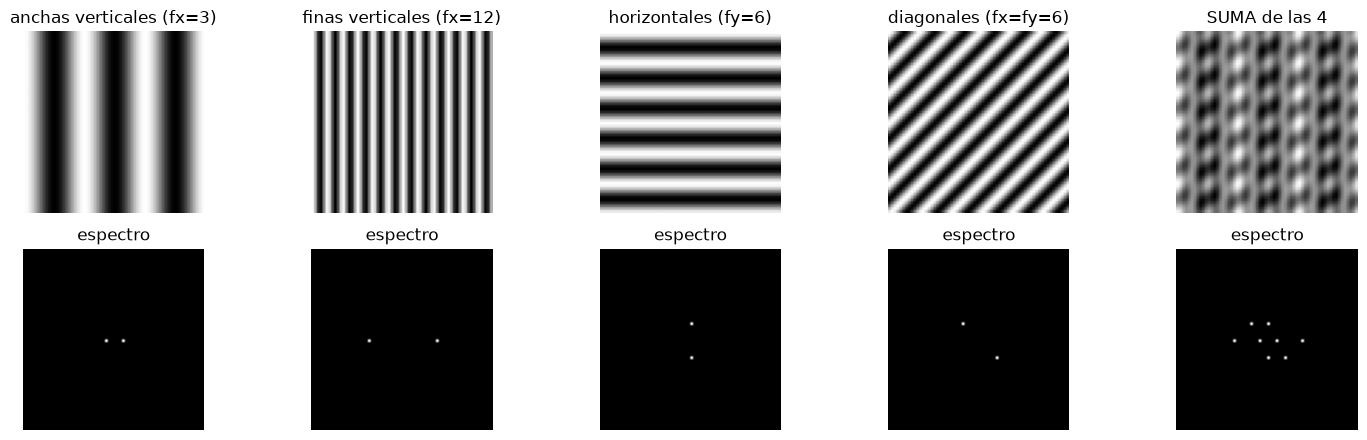

In [2]:
def grating(shape, fx, fy, phase=0.0):
    # Patrón rayado con fx ciclos a lo ancho y fy a lo alto.
    h, w = shape
    y, x = np.mgrid[:h, :w]
    return np.cos(2 * np.pi * (fx * x / w + fy * y / h) + phase)


def spectrum(img):
    # Módulo del espectro centrado, en escala log para poder verlo.
    return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(img))))


S = (64, 64)
patterns = {
    "anchas verticales (fx=3)": grating(S, 3, 0),
    "finas verticales (fx=12)": grating(S, 12, 0),
    "horizontales (fy=6)": grating(S, 0, 6),
    "diagonales (fx=fy=6)": grating(S, 6, 6),
}
patterns["SUMA de las 4"] = sum(patterns.values())
show(list(patterns.values()) + [spectrum(p) for p in patterns.values()],
     list(patterns) + ["espectro"] * len(patterns), cols=len(patterns), size=3)

Cómo leer el espectro:
- Cada patrón rayado puro es **un par de puntos** (el segundo es un espejo del primero: en imágenes reales el espectro siempre es simétrico, así que la mitad es redundante).
- **Distancia al centro = frecuencia**: las rayas finas (fx=12) caen más lejos que las anchas (fx=3).
- **Dirección desde el centro = orientación** de las rayas.
- La **suma** de los 4 patrones da una imagen enredada, pero su espectro muestra limpiamente los 4 pares de puntos: Fourier "desarma" la mezcla. Eso es lo que hace con una foto, sólo que una foto necesita miles de patrones.

### 1.2 ¿Por qué cada punto del espectro es un número complejo?
Porque para cada patrón hay que guardar **dos datos**: su *amplitud* (cuánto pesa) y su *fase* (cuánto está corrido). Un número complejo es simplemente **un par de números empaquetados**, que se puede pensar como una flecha:
- el **largo** de la flecha = amplitud → `np.abs(F)`
- el **ángulo** de la flecha = fase → `np.angle(F)`

Ejemplo: el mismo patrón, corrido un cuarto de franja. La amplitud es idéntica, sólo cambia el ángulo.

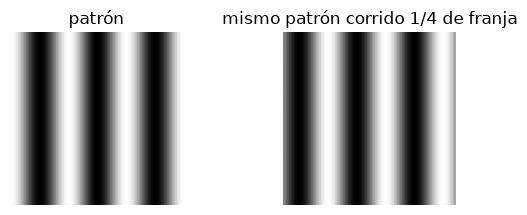

patrón  : F =  2048.0    -0.0j  ->  amplitud 2048.0, fase  -0.0°
corrido : F =     0.0 +2048.0j  ->  amplitud 2048.0, fase  90.0°


In [3]:
a, b = grating(S, 3, 0), grating(S, 3, 0, phase=np.pi / 2)
show([a, b], ["patrón", "mismo patrón corrido 1/4 de franja"], size=3)
for name, img in [("patrón", a), ("corrido", b)]:
    F = np.fft.fft2(img)[0, 3]  # fila fy=0, columna fx=3
    print(f"{name:8s}: F = {F.real:7.1f} {F.imag:+7.1f}j  ->  amplitud {abs(F):6.1f}, fase {np.degrees(np.angle(F)):5.1f}°")

**Para enfoque sólo importa la amplitud** (cuánta presencia tienen las rayas finas), no dónde están. Por eso el paper toma `abs` y descarta la fase.

### 1.3 ¿Qué es la FFT?
La **DFT** (transformada discreta de Fourier) es la cuenta: para cada patrón posible, se multiplica la imagen píxel a píxel por ese patrón y se suma todo. El resultado mide **cuánto se parece la imagen a ese patrón**. Se compara contra una versión coseno y una seno del patrón, y esos dos resultados son justamente las dos partes del número complejo.

Hecho a mano, eso cuesta $N^2$ operaciones ($N$ = cantidad de píxeles). La **FFT** (*Fast Fourier Transform*, Cooley–Tukey 1965) es un **algoritmo** que da exactamente el mismo resultado reaprovechando cuentas intermedias, en $N \log_2 N$. Para un frame de 640×360 ($N$ ≈ 230 000) eso es ~$5\cdot10^{10}$ vs ~$4\cdot10^{6}$ operaciones: unas **12 000 veces más rápido**. `np.fft.fft2` es la FFT en 2D.

Verificación: la "comparación a mano" contra un patrón da lo mismo que la FFT.

In [4]:
img = gray[0].astype(np.float64)
h, w = img.shape
fx, fy = 5, 2
y, x = np.mgrid[:h, :w]
by_hand = np.sum(img * np.exp(-2j * np.pi * (fx * x / w + fy * y / h)))  # exp = cos - j·sen
print(f"a mano: {by_hand:.1f}\nFFT   : {np.fft.fft2(img)[fy, fx]:.1f}")

a mano: -43241.5-111242.9j
FFT   : -43241.5-111242.9j


## 2. Del espectro al enfoque

Desenfocar una imagen es **apagar sus rayas finas**: los bordes nítidos, el texto y las texturas se construyen con patrones de alta frecuencia, y el desenfoque los atenúa. En el espectro, la energía que estaba repartida lejos del centro se concentra en una mancha central.

Eso es lo que explota la métrica del paper, **FM** (*Frequency domain image blur Measure*): cuenta qué fracción de los patrones tiene un peso mayor a 1/1000 del más fuerte. Imagen nítida → muchos patrones significativos → FM alta. El más fuerte es siempre el punto central (brillo promedio), así que el umbral es relativo al brillo y un cambio de iluminación global no altera el conteo.

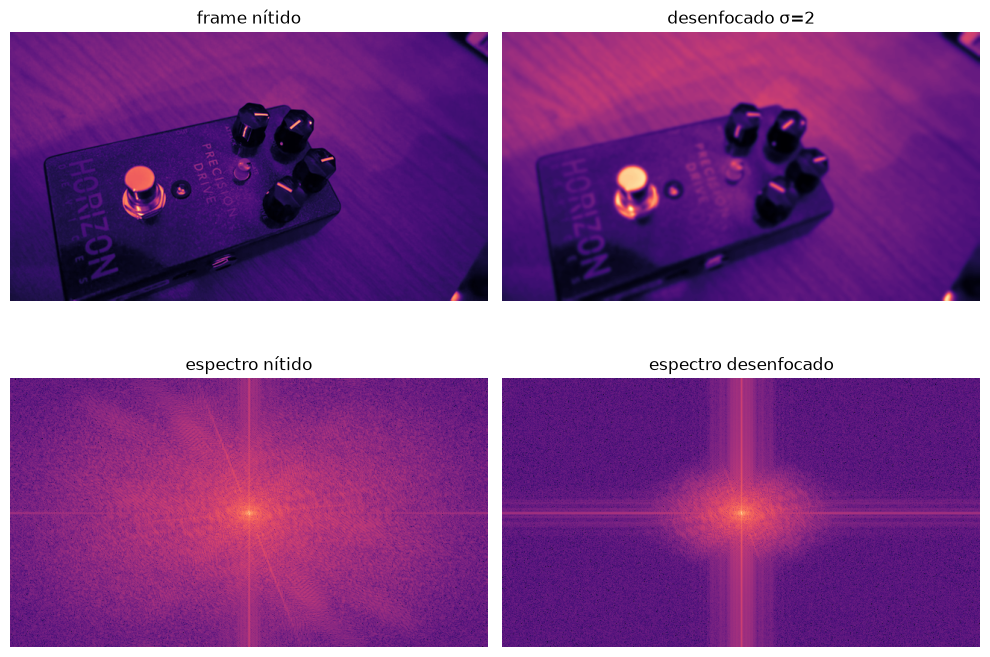

In [5]:
sharp = gray[SHARP]
show([sharp, gaussian_blur(sharp, 2), spectrum(sharp), spectrum(gaussian_blur(sharp, 2))],
     ["frame nítido", "desenfocado σ=2", "espectro nítido", "espectro desenfocado"], cols=2, cmap="magma", size=5)

## 3. Ventana de Hann

### El problema: la FFT cree que la imagen es un mosaico
Fourier describe la imagen con patrones rayados, que **se repiten infinitamente**. Por eso, sin que se lo pidamos, la FFT trata a la imagen como una baldosa de un mosaico infinito: el borde derecho queda pegado al izquierdo, y el de abajo al de arriba.

Si esos bordes no coinciden (casi nunca coinciden), en cada unión hay un **salto brusco de brillo**. Para la FFT ese salto es un borde nítido falso, así que aparecen rayas finas que la foto no tiene. En el espectro se ve como una **cruz** brillante que atraviesa el centro.

Para una métrica de enfoque es un problema: ese "detalle" falso existe **aunque la imagen esté totalmente desenfocada**, e infla FM con un piso constante.

### La solución: apagar suavemente los bordes
La **ventana de Hann** es una máscara con forma de campana: vale 1 en el centro y baja suavemente hasta 0 en los bordes. Multiplicar la imagen por ella hace que los bordes se fundan a negro, entonces al armar el mosaico **no hay costuras** y la cruz desaparece. El costo es que los píxeles cerca del borde pesan menos en la medición (poco importa: el sujeto está en el centro).

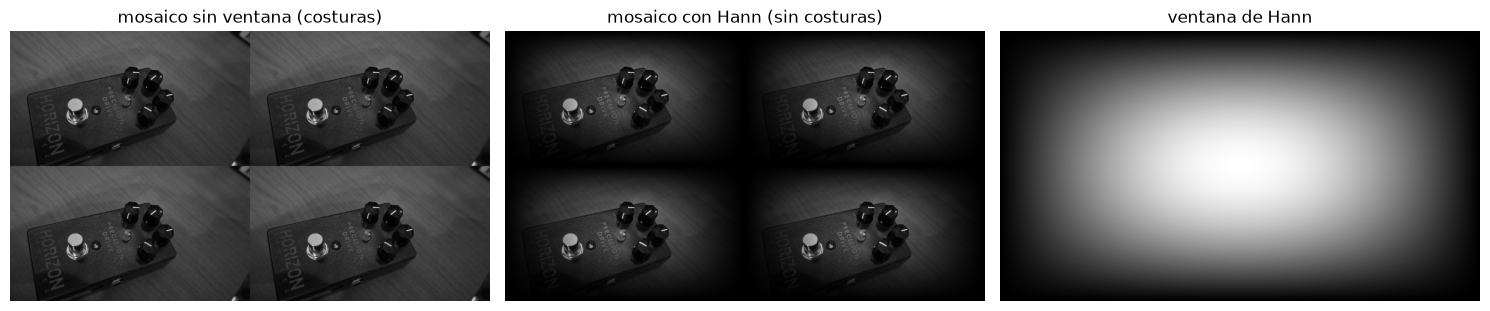

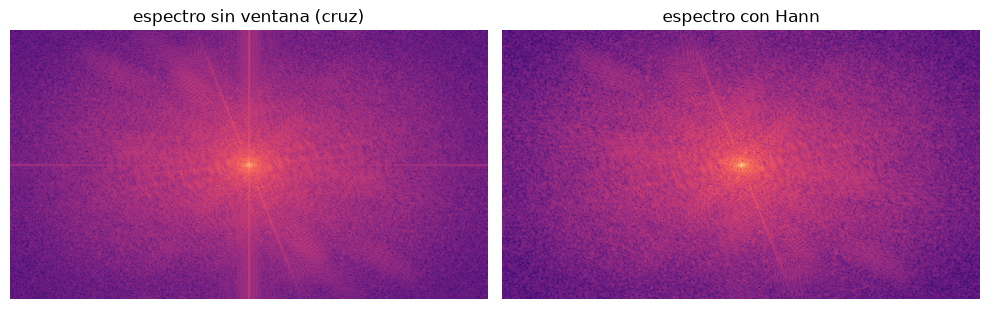

In [6]:
def tile(img):
    return np.tile(img, (2, 2))


g = gray[SHARP].astype(np.float64)
gw = g * hann(g.shape)
show([tile(g), tile(gw), hann(g.shape)], ["mosaico sin ventana (costuras)", "mosaico con Hann (sin costuras)", "ventana de Hann"], size=5)
show([spectrum(g), spectrum(gw)], ["espectro sin ventana (cruz)", "espectro con Hann"], cmap="magma", size=5)